##R Porgramming LAB 8: High-Performance Big Data Analytics Using R

## 1. Environment Setup

### 1.1 Install Packages

In [ ]:
pkgs <- c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark",
          "purrr", "lubridate", "nanoparquet", "bench", "scales")

missing_pkgs <- pkgs[!pkgs %in% rownames(installed.packages())]

if (length(missing_pkgs) > 0) {
    install.packages(missing_pkgs, repos = "https://cloud.r-project.org", Ncpus = 2)
}

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘profmem’




### 1.2 Load Libraries

In [ ]:
suppressPackageStartupMessages({
    library(data.table)
    library(ggplot2)
    library(foreach)
    library(doParallel)
    library(microbenchmark)
    library(purrr)
    library(lubridate)
    library(scales)
})

set.seed(42)
options(datatable.print.nrows = 20, width = 120)
cat("data.table threads:", getDTthreads(), "\n")
cat("CPU cores:", parallel::detectCores(), "\n")

data.table threads: 1 
CPU cores: 2 


## 2. Task 1: Data Acquisition and Preparation

### 2.1 Download Data from Official Links

In [ ]:
months <- sprintf("2023-%02d", 1:3)
trip_base_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
zone_url <- "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

dir.create("data", showWarnings = FALSE)

trip_files <- file.path("data", sprintf("yellow_tripdata_%s.parquet", months))
zone_file <- file.path("data", "taxi_zone_lookup.csv")

for (i in seq_along(months)) {
    if (!file.exists(trip_files[i])) {
        download.file(
            url = paste0(trip_base_url, basename(trip_files[i])),
            destfile = trip_files[i],
            mode = "wb",
            quiet = TRUE
        )
    }
}

if (!file.exists(zone_file)) {
    download.file(zone_url, zone_file, mode = "wb", quiet = TRUE)
}

data.frame(file = basename(c(trip_files, zone_file)),
           size_MB = round(file.size(c(trip_files, zone_file)) / 1024^2, 2))

file,size_MB
<chr>,<dbl>
yellow_tripdata_2023-01.parquet,45.46
yellow_tripdata_2023-02.parquet,45.54
yellow_tripdata_2023-03.parquet,53.53
taxi_zone_lookup.csv,0.01


### 2.2 Import Trips and Zone Lookup

In [ ]:
keep_cols <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
               "trip_distance", "PULocationID", "DOLocationID", "payment_type",
               "fare_amount", "tip_amount", "tolls_amount", "total_amount")

trips <- rbindlist(
    lapply(trip_files, function(f) {
        as.data.table(nanoparquet::read_parquet(f, col_select = keep_cols))
    }),
    use.names = TRUE
)

zones <- fread(zone_file)

cat("Trips:", format(nrow(trips), big.mark = ","), "rows\n")
cat("Zones:", nrow(zones), "rows\n")

Trips: 9,384,487 rows
Zones: 265 rows


### 2.3 Inspect Structure, Dimensions, Types and Summary

In [ ]:
dim(trips)
str(trips)
summary(trips)
cat("Memory:", format(object.size(trips), units = "MB"), "\n")
head(trips)

[1] 9384487      11

Classes ‘data.table’ and 'data.frame':	9384487 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2023-01-01 00:32:10" "2023-01-01 00:55:08" "2023-01-01 00:25:04" "2023-01-01 00:03:48" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2023-01-01 00:40:36" "2023-01-01 01:01:27" "2023-01-01 00:37:49" "2023-01-01 00:13:25" ...
 $ passenger_count      : num  1 1 1 0 1 1 1 1 1 1 ...
 $ trip_distance        : num  0.97 1.1 2.51 1.9 1.43 1.84 1.66 11.7 2.95 3.01 ...
 $ PULocationID         : num  161 43 48 138 107 161 239 142 164 141 ...
 $ DOLocationID         : num  141 237 238 7 79 137 143 200 236 107 ...
 $ payment_type         : num  2 1 1 1 1 1 1 1 1 2 ...
 $ fare_amount          : num  9.3 7.9 14.9 12.1 11.4 12.8 12.1 45.7 17.7 14.9 ...
 $ tip_amount           : num  0 4 15 0 3.28 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 3 0 0 ...
 $ total_amount         : num  14.3 16.9 34.9 20.9 19.7 ...
 - attr(*, ".internal.selfref")=<pointer: 0x5c3fa23ed3f0> 


 tpep_pickup_datetime          tpep_dropoff_datetime         passenger_count  trip_distance       PULocationID
 Min.   :2001-01-01 00:06:49   Min.   :2001-01-01 14:13:51   Min.   :0.000    Min.   :0.00e+00   Min.   :  1  
 1st Qu.:2023-01-24 23:33:22   1st Qu.:2023-01-24 23:48:47   1st Qu.:1.000    1st Qu.:1.06e+00   1st Qu.:132  
 Median :2023-02-16 14:58:37   Median :2023-02-16 15:17:08   Median :1.000    Median :1.79e+00   Median :162  
 Mean   :2023-02-16 05:29:55   Mean   :2023-02-16 05:46:08   Mean   :1.355    Mean   :3.87e+00   Mean   :166  
 3rd Qu.:2023-03-10 14:34:35   3rd Qu.:2023-03-10 14:54:20   3rd Qu.:1.000    3rd Qu.:3.33e+00   3rd Qu.:234  
 Max.   :2023-04-05 20:17:42   Max.   :2023-04-05 20:35:28   Max.   :9.000    Max.   :3.35e+05   Max.   :265  
                                                             NAs    :236179                                   
  DOLocationID    payment_type    fare_amount        tip_amount       tolls_amount       total_amount    
 Min. 

Memory: 787.6 Mb 


tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2023-01-01 00:32:10,2023-01-01 00:40:36,1,0.97,161,141,2,9.3,0.00,0,14.30
2023-01-01 00:55:08,2023-01-01 01:01:27,1,1.10,43,237,1,7.9,4.00,0,16.90
2023-01-01 00:25:04,2023-01-01 00:37:49,1,2.51,48,238,1,14.9,15.00,0,34.90
2023-01-01 00:03:48,2023-01-01 00:13:25,0,1.90,138,7,1,12.1,0.00,0,20.85
2023-01-01 00:10:29,2023-01-01 00:21:19,1,1.43,107,79,1,11.4,3.28,0,19.68
2023-01-01 00:50:34,2023-01-01 01:02:52,1,1.84,161,137,1,12.8,10.00,0,27.80


### 2.4 Detect Missing and Duplicate Records

In [ ]:
colSums(is.na(trips))
cat("Duplicate rows:", nrow(trips) - uniqueN(trips), "\n")
cat("Zero or negative distance:", trips[trip_distance <= 0, .N], "\n")
cat("Negative fare:", trips[fare_amount < 0, .N], "\n")
cat("Passenger count 0 or above 6:", trips[passenger_count == 0 | passenger_count > 6, .N], "\n")

tpep_pickup_datetime tpep_dropoff_datetime       passenger_count         trip_distance          PULocationID 
                    0                     0                236179                     0                     0 
         DOLocationID          payment_type           fare_amount            tip_amount          tolls_amount 
                    0                     0                     0                     0                     0 
         total_amount 
                    0

Duplicate rows: 0 
Zero or negative distance: 135488 
Negative fare: 79490 
Passenger count 0 or above 6: 156861 


### 2.5 Clean Invalid Records and Convert Data Types

In [ ]:
n_raw <- nrow(trips)

trips <- unique(trips)
trips <- trips[!is.na(passenger_count)]

trips[, duration_min := (as.numeric(tpep_dropoff_datetime) - as.numeric(tpep_pickup_datetime)) / 60]

start_time <- as.POSIXct(paste0(months[1], "-01"), tz = "UTC")
end_time <- as.POSIXct(seq(as.Date(paste0(tail(months, 1), "-01")), by = "month", length.out = 2)[2], tz = "UTC")

trips <- trips[
    tpep_pickup_datetime >= start_time & tpep_pickup_datetime < end_time &
    duration_min > 1 & duration_min < 300 &
    trip_distance > 0.1 & trip_distance < 100 &
    fare_amount >= 2.5 & fare_amount < 500 &
    total_amount > 0 & total_amount < 1000 &
    tip_amount >= 0 & tolls_amount >= 0 &
    passenger_count >= 1 & passenger_count <= 6 &
    payment_type %in% 1:4
]

pay_labels <- c("Credit card", "Cash", "No charge", "Dispute")

trips[, `:=`(
    passenger_count = as.integer(passenger_count),
    PULocationID = as.integer(PULocationID),
    DOLocationID = as.integer(DOLocationID),
    payment_type = factor(payment_type, levels = 1:4, labels = pay_labels)
)]

cat("Raw rows:", format(n_raw, big.mark = ","), "\n")
cat("Clean rows:", format(nrow(trips), big.mark = ","), "\n")
cat("Retained:", round(100 * nrow(trips) / n_raw, 2), "%\n")

Raw rows: 9,384,487 
Clean rows: 8,763,337 
Retained: 93.38 %


### 2.6 Extract Temporal Attributes and Drop Unneeded Columns

In [ ]:
trips[, `:=`(
    hour = hour(tpep_pickup_datetime),
    day = mday(tpep_pickup_datetime),
    wday = factor(wday(tpep_pickup_datetime), levels = 1:7,
                  labels = c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat")),
    month = month(tpep_pickup_datetime)
)]

trips[, c("tpep_pickup_datetime", "tpep_dropoff_datetime") := NULL]

gc()
cat("Memory:", format(object.size(trips), units = "MB"), "\n")
head(trips)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1275851,68.2,2515760,134.4,2155643,115.2
Vcells,94360666,720.0,303249923,2313.7,303182353,2313.1


Memory: 702 Mb 


passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,duration_min,hour,day,wday,month
<int>,<dbl>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<fct>,<dbl>
1,0.97,161,141,Cash,9.3,0.00,0,14.30,8.433333,0,1,Sun,1
1,1.10,43,237,Credit card,7.9,4.00,0,16.90,6.316667,0,1,Sun,1
1,2.51,48,238,Credit card,14.9,15.00,0,34.90,12.750000,0,1,Sun,1
1,1.43,107,79,Credit card,11.4,3.28,0,19.68,10.833333,0,1,Sun,1
1,1.84,161,137,Credit card,12.8,10.00,0,27.80,12.300000,0,1,Sun,1
1,1.66,239,143,Credit card,12.1,3.42,0,20.52,10.450000,0,1,Sun,1


### 2.7 Join Trips with Taxi Zone Lookup (Pickup and Drop-off)

In [ ]:
trips <- merge(
    trips,
    zones[, .(PULocationID = LocationID, PUBorough = Borough, PUZone = Zone)],
    by = "PULocationID",
    all.x = TRUE
)

trips <- merge(
    trips,
    zones[, .(DOLocationID = LocationID, DOBorough = Borough, DOZone = Zone)],
    by = "DOLocationID",
    all.x = TRUE
)

cat("Rows after join:", format(nrow(trips), big.mark = ","), "\n")
cat("Unmatched pickup zones:", trips[is.na(PUZone), .N], "\n")
head(trips)

Rows after join: 8,763,337 
Unmatched pickup zones: 0 


DOLocationID,PULocationID,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,duration_min,hour,day,wday,month,PUBorough,PUZone,DOBorough,DOZone
<int>,<int>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,1,1,17.71,Cash,122.70,0.00,11.75,138.45,36.216667,13,1,Sun,1,EWR,Newark Airport,EWR,Newark Airport
1,1,3,0.23,Credit card,30.00,0.00,0.00,31.00,1.550000,15,1,Sun,1,EWR,Newark Airport,EWR,Newark Airport
1,1,1,16.60,Credit card,134.00,5.00,0.00,140.00,1.383333,14,2,Mon,1,EWR,Newark Airport,EWR,Newark Airport
1,1,1,0.32,Credit card,110.00,26.26,20.30,157.56,2.183333,7,9,Mon,1,EWR,Newark Airport,EWR,Newark Airport
1,1,2,0.70,No charge,96.23,0.00,0.00,97.23,4.550000,12,15,Sun,1,EWR,Newark Airport,EWR,Newark Airport
1,1,1,0.70,Credit card,100.00,10.00,0.00,111.00,3.316667,18,15,Sun,1,EWR,Newark Airport,EWR,Newark Airport


## 3. Task 2: Transportation Data Analytics

### 3.1 Trips by Hour of Day

In [ ]:
hourly <- trips[, .(trips = .N), by = hour][order(hour)]
hourly
cat("Peak hour:", hourly[which.max(trips), hour], "\n")

hour,trips
<int>,<int>
0,236806
1,158929
2,103419
3,70286
4,44683
5,47311
6,120141
7,240643
8,332210


Peak hour: 18 


### 3.2 Demand by Day of Week

In [ ]:
dow <- trips[, .(trips = .N, share_pct = round(100 * .N / nrow(trips), 2)), by = wday][order(wday)]
dow

wday,trips,share_pct
<fct>,<int>,<dbl>
Sun,1101327,12.57
Mon,1066893,12.17
Tue,1248477,14.25
Wed,1333802,15.22
Thu,1398836,15.96
Fri,1368485,15.62
Sat,1245517,14.21


### 3.3 Monthly Variation, Average Fare and Revenue

In [ ]:
monthly <- trips[, .(
    trips = .N,
    avg_fare = round(mean(fare_amount), 2),
    avg_total = round(mean(total_amount), 2),
    revenue = round(sum(total_amount))
), by = month][order(month)]
monthly

month,trips,avg_fare,avg_total,revenue
<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,2870082,18.52,27.34,78464457
2,2719233,18.42,27.28,74183991
3,3174022,19.11,28.20,89512498


### 3.4 Average Fare and Revenue by Time Period

In [ ]:
trips[, period := fcase(
    hour < 6, "Night 00-05",
    hour < 12, "Morning 06-11",
    hour < 18, "Afternoon 12-17",
    default = "Evening 18-23"
)]

period_summary <- trips[, .(
    trips = .N,
    avg_fare = round(mean(fare_amount), 2),
    revenue = round(sum(total_amount))
), by = period][order(-revenue)]

weekday_summary <- trips[, .(
    avg_fare = round(mean(fare_amount), 2),
    revenue = round(sum(total_amount))
), by = wday][order(wday)]

period_summary
weekday_summary

period,trips,avg_fare,revenue
<chr>,<int>,<dbl>,<dbl>
Afternoon 12-17,3219714,19.22,90781225
Evening 18-23,2963142,18.29,82422126
Morning 06-11,1919047,18.26,50343801
Night 00-05,661434,19.29,18613794


wday,avg_fare,revenue
<fct>,<dbl>,<dbl>
Sun,19.82,31454294
Mon,19.55,30747386
Tue,18.41,34274356
Wed,18.49,36799564
Thu,18.75,39042508
Fri,18.49,37810420
Sat,17.68,32032418


### 3.5 Most Frequent Routes

In [ ]:
routes <- trips[, .(
    trips = .N,
    revenue = sum(total_amount),
    avg_fare = mean(fare_amount)
), by = .(PUZone, DOZone)]

top_routes <- routes[order(-trips)][1:15][, route := paste(PUZone, DOZone, sep = " -> ")]
top_routes[, .(route, trips, avg_fare = round(avg_fare, 2))]

route,trips,avg_fare
<chr>,<int>,<dbl>
Upper East Side South -> Upper East Side North,61219,8.65
N/A -> N/A,54860,19.09
Upper East Side North -> Upper East Side South,52065,9.29
Upper East Side North -> Upper East Side North,39233,6.72
Upper East Side South -> Upper East Side South,38218,7.16
Midtown Center -> Upper East Side South,27368,9.78
Upper East Side South -> Midtown Center,26708,9.82
Midtown Center -> Upper East Side North,24896,13.66
Lincoln Square East -> Upper West Side South,23516,8.02


### 3.6 Highest-Revenue Routes

In [ ]:
top_revenue_routes <- routes[order(-revenue)][1:15][, route := paste(PUZone, DOZone, sep = " -> ")]
top_revenue_routes[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))]

route,trips,revenue,avg_fare
<chr>,<int>,<dbl>,<dbl>
JFK Airport -> Outside of NYC,14300,1744342,103.10
JFK Airport -> Times Sq/Theatre District,18769,1733748,70.11
N/A -> N/A,54860,1495243,19.09
LaGuardia Airport -> Times Sq/Theatre District,16737,1244243,47.14
JFK Airport -> Clinton East,12067,1103061,70.08
Upper East Side South -> Upper East Side North,61219,944348,8.65
JFK Airport -> Midtown South,9836,922057,70.10
Upper East Side North -> Upper East Side South,52065,835949,9.29
JFK Airport -> Murray Hill,8593,804936,69.97


### 3.7 Trip Distance vs Fare Relationship

In [ ]:
cat("Correlation (distance, fare):", round(cor(trips$trip_distance, trips$fare_amount), 4), "\n")

lm_fit <- lm(fare_amount ~ trip_distance, data = trips[sample(.N, 500000)])
print(round(coef(lm_fit), 3))
cat("R-squared:", round(summary(lm_fit)$r.squared, 4), "\n")

trips[, dist_band := cut(trip_distance, breaks = c(0, 1, 2, 5, 10, 20, Inf),
                         labels = c("0-1", "1-2", "2-5", "5-10", "10-20", "20+"))]

distance_summary <- trips[, .(
    trips = .N,
    avg_fare = round(mean(fare_amount), 2),
    fare_per_mile = round(mean(fare_amount / trip_distance), 2)
), by = dist_band][order(dist_band)]
distance_summary

Correlation (distance, fare): 0.964 
  (Intercept) trip_distance 
        6.011         3.712 
R-squared: 0.9311 


dist_band,trips,avg_fare,fare_per_mile
<fct>,<int>,<dbl>,<dbl>
0-1,1935842,7.35,10.87
1-2,2937956,11.32,7.81
2-5,2431616,18.43,6.24
5-10,737998,33.87,4.72
10-20,629334,61.41,4.14
20+,90591,87.66,3.67


### 3.8 Payment Methods Across Boroughs

In [ ]:
pay_borough <- trips[!is.na(PUBorough), .N, by = .(PUBorough, payment_type)]
pay_borough[, share_pct := round(100 * N / sum(N), 2), by = PUBorough]
pay_borough[order(PUBorough, -N)]

PUBorough,payment_type,N,share_pct
<chr>,<fct>,<int>,<dbl>
Bronx,Credit card,7986,82.82
Bronx,Cash,1550,16.07
Bronx,Dispute,67,0.69
Bronx,No charge,40,0.41
Brooklyn,Credit card,31784,80.35
Brooklyn,Cash,7267,18.37
Brooklyn,Dispute,298,0.75
Brooklyn,No charge,208,0.53
EWR,Credit card,47,73.44


### 3.9 Additional Patterns: Tipping, Airport Trips, Speed

In [ ]:
trips[, tip_pct := fifelse(fare_amount > 0, 100 * tip_amount / fare_amount, 0)]

tip_payment <- trips[, .(avg_tip_pct = round(mean(tip_pct), 2)), by = payment_type][order(-avg_tip_pct)]

airport_ids <- zones[grepl("Airport", Zone), LocationID]

airport_summary <- trips[, .(
    trips = .N,
    avg_fare = round(mean(fare_amount), 2),
    avg_distance = round(mean(trip_distance), 2),
    avg_tip_pct = round(mean(tip_pct), 2)
), by = .(airport_trip = PULocationID %in% airport_ids | DOLocationID %in% airport_ids)]

speed_hour <- trips[, .(avg_speed_mph = round(mean(trip_distance / (duration_min / 60)), 2)), by = hour][order(hour)]

tip_payment
airport_summary
speed_hour

payment_type,avg_tip_pct
<fct>,<dbl>
Credit card,25.17
Dispute,0.11
No charge,0.06
Cash,0.00


airport_trip,trips,avg_fare,avg_distance,avg_tip_pct
<lgl>,<int>,<dbl>,<dbl>,<dbl>
TRUE,894821,55.70,13.67,16.85
FALSE,7868516,14.49,2.25,21.14


hour,avg_speed_mph
<int>,<dbl>
0,15.34
1,14.92
2,14.95
3,15.89
4,18.77
5,20.65
6,16.88
7,13.47
8,11.41


## 4. Task 3: Functional vs Vectorized vs data.table

### 4.1 Operation A: Average Fare per Hour (Five Implementations)

In [ ]:
hr <- trips$hour
fr <- trips$fare_amount

f_lapply <- function() unlist(lapply(0:23, function(h) mean(fr[hr == h])))
f_map <- function() map_dbl(0:23, function(h) mean(fr[hr == h]))
f_vector <- function() as.vector(rowsum(fr, hr)) / tabulate(hr + 1L, 24)
f_base <- function() as.numeric(tapply(fr, hr, mean))
f_dt <- function() trips[, mean(fare_amount), keyby = hour]$V1

ref <- f_dt()
sapply(list(lapply = f_lapply(), map = f_map(), vectorized = f_vector(), base_tapply = f_base()),
       function(x) isTRUE(all.equal(x, ref)))

lapply         map  vectorized base_tapply 
       TRUE        TRUE        TRUE        TRUE

### 4.2 Benchmark Operation A (Execution Time)

In [ ]:
mb_hour <- microbenchmark(
    lapply_functional = f_lapply(),
    purrr_map_functional = f_map(),
    vectorized_rowsum = f_vector(),
    base_tapply = f_base(),
    data_table = f_dt(),
    times = 10
)

print(mb_hour, unit = "ms")

Unit: milliseconds
                 expr       min        lq      mean    median        uq       max neval
    lapply_functional 1208.8115 1216.0791 1351.9889 1243.0967 1319.6308 1945.9994    10
 purrr_map_functional 1191.4570 1232.7914 1359.1911 1239.7130 1461.8569 1870.3976    10
    vectorized_rowsum  322.9048  338.4086  388.4486  348.6068  463.0466  521.2789    10
          base_tapply  619.5152  647.6458  704.3504  659.0021  692.8872 1098.2473    10
           data_table  270.2638  320.0911  353.2131  324.8362  344.0362  535.5666    10


### 4.3 Memory Allocation for Operation A

In [ ]:
mem_hour <- bench::mark(
    lapply_functional = f_lapply(),
    purrr_map_functional = f_map(),
    vectorized_rowsum = f_vector(),
    data_table = f_dt(),
    check = FALSE,
    iterations = 5
)

as.data.frame(mem_hour[, c("expression", "median", "mem_alloc")])

Warning message:
“Some expressions had a GC in every iteration; so filtering is disabled.”


expression,median,mem_alloc
<bch:expr>,<bch:tm>,<bch:byt>
lapply_functional,1.22s,1.67GB
purrr_map_functional,1.22s,1.67GB
vectorized_rowsum,339.52ms,228.29MB
data_table,327.77ms,246.05MB


### 4.4 Operation B: Row-wise Tip Percentage (apply, map2, vectorized, data.table)

In [ ]:
samp <- trips[sample(.N, 100000), .(fare_amount, tip_amount)]
m <- as.matrix(samp)

a_apply <- function() apply(m, 1, function(r) if (r[1] > 0) 100 * r[2] / r[1] else 0)
a_map2 <- function() map2_dbl(m[, 1], m[, 2], function(f, t) if (f > 0) 100 * t / f else 0)
a_vector <- function() ifelse(m[, 1] > 0, 100 * m[, 2] / m[, 1], 0)
a_dt <- function() samp[, fifelse(fare_amount > 0, 100 * tip_amount / fare_amount, 0)]

ref_b <- a_dt()
sapply(list(apply = a_apply(), map2 = a_map2(), vectorized = a_vector()),
       function(x) isTRUE(all.equal(as.numeric(x), ref_b)))

mb_row <- microbenchmark(
    apply_functional = a_apply(),
    purrr_map2_functional = a_map2(),
    vectorized_ifelse = a_vector(),
    data_table_fifelse = a_dt(),
    times = 10
)

print(mb_row, unit = "ms")

apply       map2 vectorized 
      TRUE       TRUE       TRUE

Unit: milliseconds
                  expr        min          lq        mean      median          uq        max neval
      apply_functional 738.250767 1059.826768 1193.431842 1169.502656 1362.611833 1672.79996    10
 purrr_map2_functional 162.797032  185.868027  251.596843  254.096068  296.985636  335.31221    10
     vectorized_ifelse   2.882482    3.020426    4.269059    3.061238    4.782049   11.33941    10
    data_table_fifelse   1.521023    1.753267    2.499357    1.794961    2.109309    7.91850    10


## 5. Task 4: Parallel Computing

### 5.1 Partition Data (Month x Day-of-Week)

In [ ]:
parts <- split(trips[, .(month, wday, fare_amount, trip_distance, total_amount)],
               by = c("month", "wday"))

cat("Partitions:", length(parts), "\n")
summary(sapply(parts, nrow))

Partitions: 21 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 332789  388670  407253  417302  427002  558547 

### 5.2 Define the Computationally Intensive Task

In [ ]:
boot_fit <- function(d, B = 200, n = 50000) {
    set.seed(100 * d$month[1] + as.integer(d$wday[1]))
    slopes <- numeric(B)
    for (b in seq_len(B)) {
        idx <- sample.int(nrow(d), min(n, nrow(d)), replace = TRUE)
        slopes[b] <- lm.fit(cbind(1, d$trip_distance[idx]), d$total_amount[idx])$coefficients[2]
    }
    data.table(month = d$month[1], wday = as.character(d$wday[1]),
               rows = nrow(d), slope_mean = mean(slopes), slope_sd = sd(slopes))
}

boot_fit(parts[[1]], B = 5)

month,wday,rows,slope_mean,slope_sd
<dbl>,<chr>,<int>,<dbl>,<dbl>
1,Sun,405992,4.55843,0.02478349


### 5.3 Sequential Processing

In [ ]:
t_seq <- system.time({
    res_seq <- foreach(d = parts, .combine = rbind, .packages = "data.table") %do% boot_fit(d)
})[["elapsed"]]

cat("Sequential time:", round(t_seq, 2), "seconds\n")
head(res_seq)

Sequential time: 29.88 seconds


month,wday,rows,slope_mean,slope_sd
<dbl>,<chr>,<int>,<dbl>,<dbl>
1,Sun,405992,4.569086,0.02127378
1,Mon,378493,4.597934,0.02270857
1,Fri,407253,4.642468,0.02147839
2,Tue,388670,4.595499,0.02376061
2,Fri,424771,4.688657,0.02437380
2,Sat,401361,4.570199,0.02160406


### 5.4 Parallel Processing with foreach and doParallel

In [ ]:
n_cores <- parallel::detectCores()
cl <- makeCluster(n_cores)
registerDoParallel(cl)

t_par <- system.time({
    res_par <- foreach(d = parts, .combine = rbind, .packages = "data.table",
                       .export = "boot_fit") %dopar% boot_fit(d)
})[["elapsed"]]

stopCluster(cl)

cat("Cores used:", n_cores, "\n")
cat("Parallel time:", round(t_par, 2), "seconds\n")
cat("Results identical:", isTRUE(all.equal(res_seq, res_par)), "\n")

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): boot_fit”


Cores used: 2 
Parallel time: 28.15 seconds
Results identical: TRUE 


### 5.5 Speedup and Efficiency

In [ ]:
speedup_tbl <- data.table(
    sequential_s = round(t_seq, 2),
    parallel_s = round(t_par, 2),
    cores = n_cores,
    speedup = round(t_seq / t_par, 2),
    efficiency_pct = round(100 * (t_seq / t_par) / n_cores, 1)
)
speedup_tbl

sequential_s,parallel_s,cores,speedup,efficiency_pct
<dbl>,<dbl>,<int>,<dbl>,<dbl>
29.88,28.15,2,1.06,53.1


## 6. Task 5: Performance Benchmarking and Optimization

### 6.1 Base R vs Functional vs data.table (Grouped Mean, 1M Rows)

In [ ]:
sub <- trips[sample(.N, 1000000), .(PUBorough, payment_type, total_amount)]
sub_df <- as.data.frame(sub)

g_base_aggregate <- function() aggregate(total_amount ~ PUBorough + payment_type, data = sub_df, FUN = mean)
g_base_tapply <- function() tapply(sub_df$total_amount, list(sub_df$PUBorough, sub_df$payment_type), mean)
g_functional <- function() lapply(split(sub_df$total_amount, paste(sub_df$PUBorough, sub_df$payment_type)), mean)
g_dt <- function() sub[, .(avg_total = mean(total_amount)), by = .(PUBorough, payment_type)]

mb_group <- microbenchmark(
    base_aggregate = g_base_aggregate(),
    base_tapply = g_base_tapply(),
    functional_split_lapply = g_functional(),
    data_table = g_dt(),
    times = 5
)

print(mb_group, unit = "ms")

Unit: milliseconds
                    expr       min        lq      mean    median        uq       max neval
          base_aggregate 568.40547 576.81301 700.64270 695.90225 721.71687 940.37588     5
             base_tapply  81.47427  81.58027 102.88127  83.32673  84.83398 183.19109     5
 functional_split_lapply 291.48815 335.77305 467.29730 560.02771 571.05109 578.14650     5
              data_table  47.61966  47.98389  57.00423  48.25389  49.42458  91.73913     5


### 6.2 Execution-Time Comparison Table

In [ ]:
collect <- function(mb, task) {
    s <- as.data.table(summary(mb, unit = "ms"))
    s[, .(task = task, method = as.character(expr), median_ms = round(median, 2))]
}

par_rows <- data.table(
    task = "Sequential vs parallel (bootstrap, 21 partitions)",
    method = c("sequential_foreach", paste0("parallel_foreach_", n_cores, "_cores")),
    median_ms = round(c(t_seq, t_par) * 1000, 2)
)

results_all <- rbindlist(list(
    collect(mb_hour, "A: Avg fare per hour (9M rows)"),
    collect(mb_row, "B: Row-wise tip % (100k rows)"),
    collect(mb_group, "C: Grouped mean (1M rows)"),
    par_rows
))

results_all[, rel_to_fastest := round(median_ms / min(median_ms), 1), by = task]
results_all

task,method,median_ms,rel_to_fastest
<chr>,<chr>,<dbl>,<dbl>
A: Avg fare per hour (9M rows),lapply_functional,1243.10,3.8
A: Avg fare per hour (9M rows),purrr_map_functional,1239.71,3.8
A: Avg fare per hour (9M rows),vectorized_rowsum,348.61,1.1
A: Avg fare per hour (9M rows),base_tapply,659.00,2.0
A: Avg fare per hour (9M rows),data_table,324.84,1.0
B: Row-wise tip % (100k rows),apply_functional,1169.50,653.4
B: Row-wise tip % (100k rows),purrr_map2_functional,254.10,142.0
B: Row-wise tip % (100k rows),vectorized_ifelse,3.06,1.7
B: Row-wise tip % (100k rows),data_table_fifelse,1.79,1.0


### 6.3 Scalability Test (Growing Data Size)

In [ ]:
sizes <- c(1e5, 1e6, nrow(trips))

scalability <- rbindlist(lapply(sizes, function(n) {
    s <- trips[sample(.N, n), .(hour, fare_amount)]
    h <- s$hour
    f <- s$fare_amount
    data.table(
        rows = n,
        lapply_s = system.time(lapply(0:23, function(k) mean(f[h == k])))[["elapsed"]],
        vectorized_s = system.time(rowsum(f, h) / tabulate(h + 1L, 24))[["elapsed"]],
        data_table_s = system.time(s[, mean(fare_amount), by = hour])[["elapsed"]]
    )
}))

scalability

rows,lapply_s,vectorized_s,data_table_s
<dbl>,<dbl>,<dbl>,<dbl>
100000,0.010,0.003,0.004
1000000,0.114,0.025,0.023
8763337,1.224,0.288,0.262


## 7. Task 6: Data Visualization (ggplot2)

### 7.1 Number of Trips by Hour

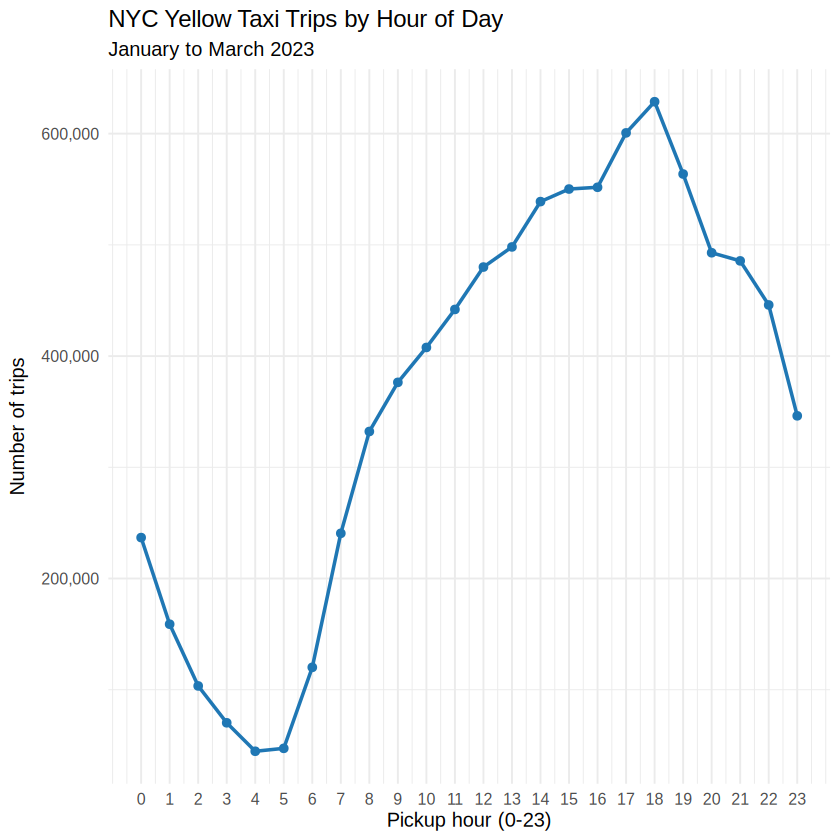

In [ ]:
theme_set(theme_minimal(base_size = 12))

ggplot(hourly, aes(x = hour, y = trips)) +
    geom_line(linewidth = 1, colour = "#1f77b4") +
    geom_point(size = 2, colour = "#1f77b4") +
    scale_x_continuous(breaks = 0:23) +
    scale_y_continuous(labels = comma) +
    labs(title = "NYC Yellow Taxi Trips by Hour of Day",
         subtitle = "January to March 2023",
         x = "Pickup hour (0-23)", y = "Number of trips")

### 7.2 Taxi Demand by Day of Week

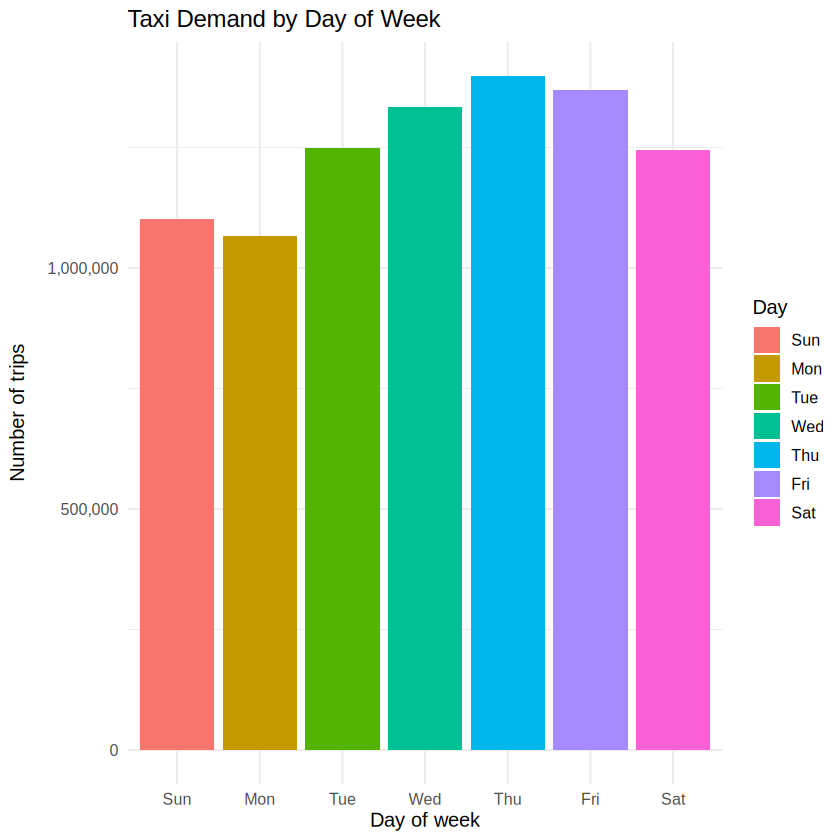

In [ ]:
ggplot(dow, aes(x = wday, y = trips, fill = wday)) +
    geom_col() +
    scale_y_continuous(labels = comma) +
    labs(title = "Taxi Demand by Day of Week",
         x = "Day of week", y = "Number of trips", fill = "Day")

### 7.3 Monthly Taxi Demand

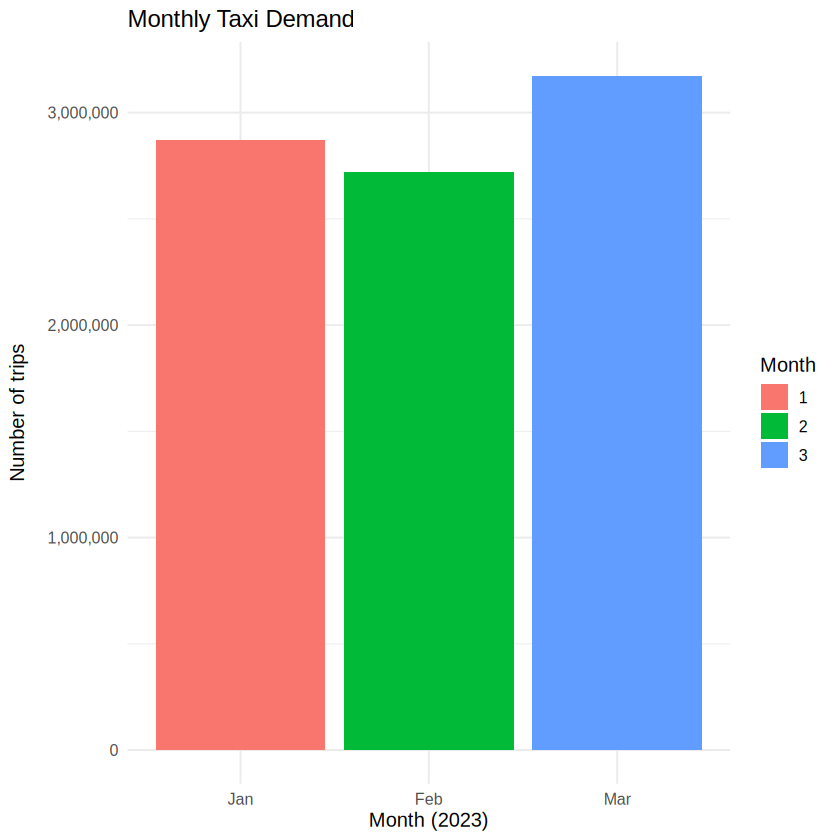

In [ ]:
ggplot(monthly, aes(x = factor(month, labels = month.abb[monthly$month]), y = trips, fill = factor(month))) +
    geom_col() +
    scale_y_continuous(labels = comma) +
    labs(title = "Monthly Taxi Demand",
         x = "Month (2023)", y = "Number of trips", fill = "Month")

### 7.4 Average Fare Trend by Hour

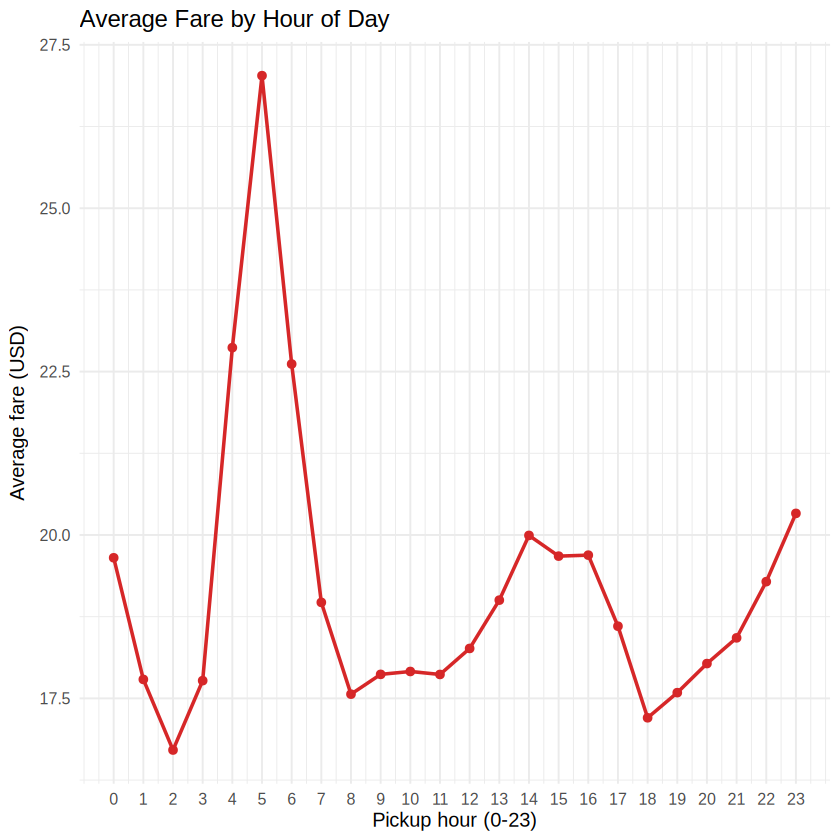

In [ ]:
avg_fare_hour <- trips[, .(avg_fare = mean(fare_amount)), by = hour][order(hour)]

ggplot(avg_fare_hour, aes(x = hour, y = avg_fare)) +
    geom_line(linewidth = 1, colour = "#d62728") +
    geom_point(size = 2, colour = "#d62728") +
    scale_x_continuous(breaks = 0:23) +
    labs(title = "Average Fare by Hour of Day",
         x = "Pickup hour (0-23)", y = "Average fare (USD)")

### 7.5 Revenue Trend (Daily)

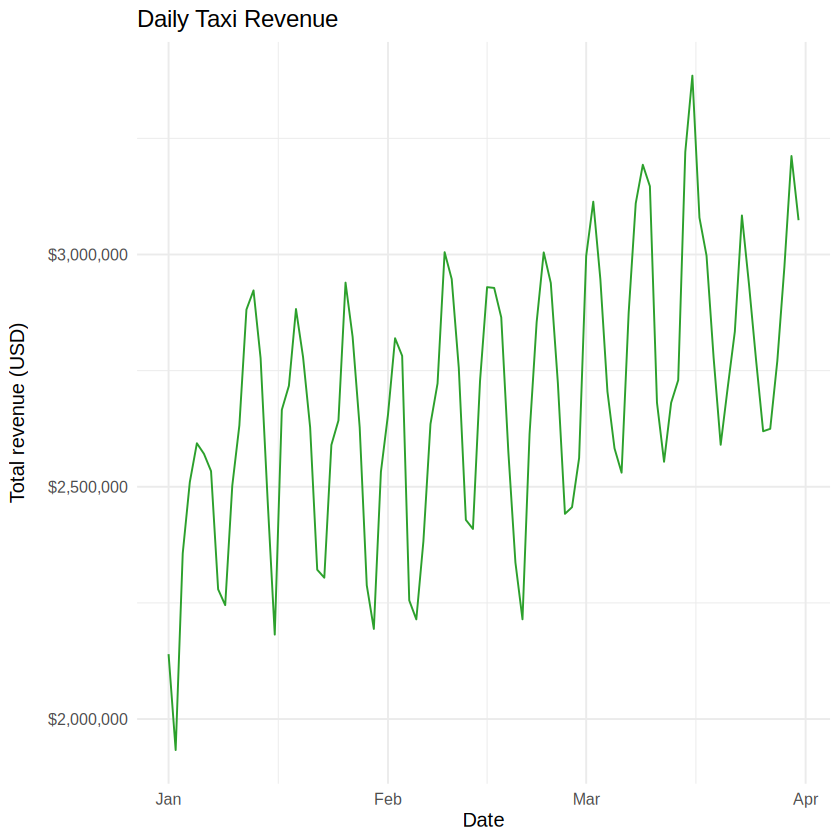

In [ ]:
daily_revenue <- trips[, .(revenue = sum(total_amount)), by = .(month, day)]
daily_revenue[, date := as.Date(sprintf("2023-%02d-%02d", month, day))]

ggplot(daily_revenue[order(date)], aes(x = date, y = revenue)) +
    geom_line(colour = "#2ca02c") +
    scale_y_continuous(labels = label_dollar()) +
    labs(title = "Daily Taxi Revenue",
         x = "Date", y = "Total revenue (USD)")

### 7.6 Top Pickup and Drop-off Locations

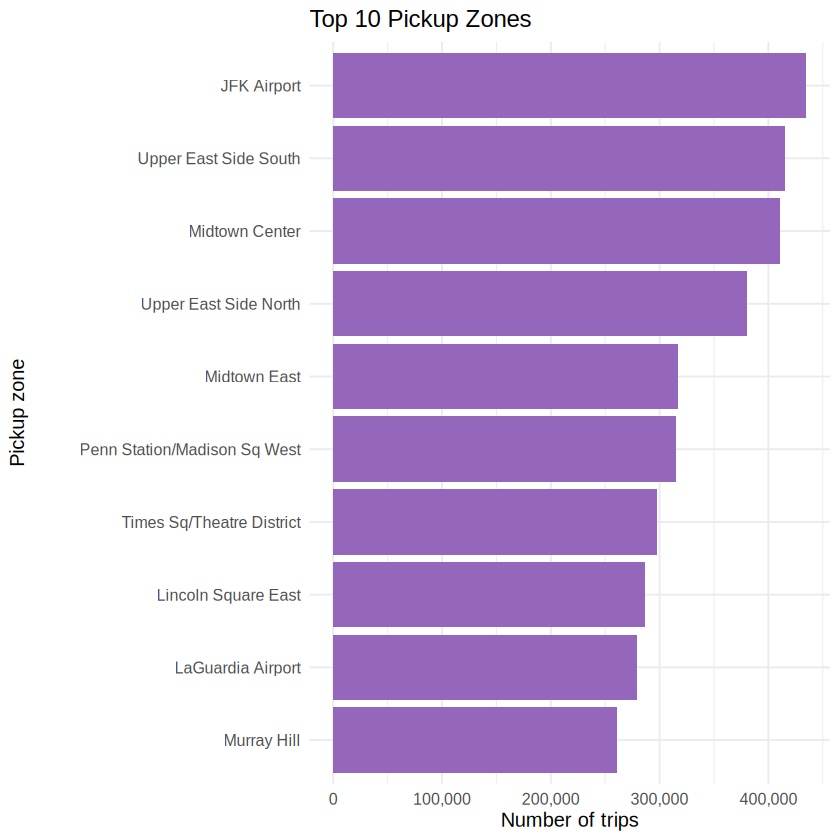

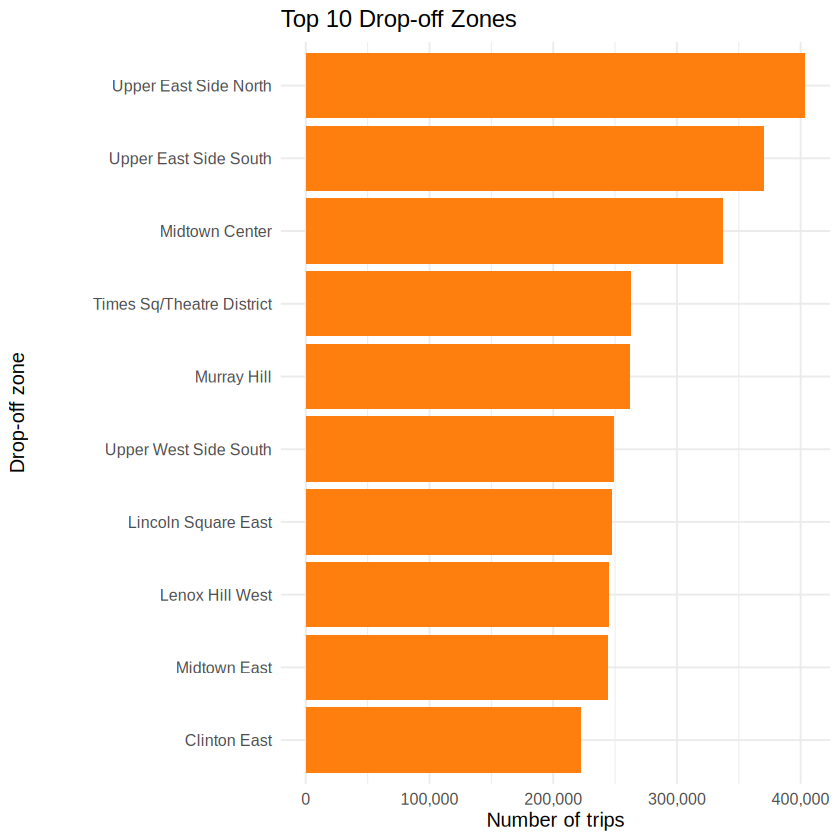

In [ ]:
top_pu <- trips[, .N, by = PUZone][order(-N)][1:10]
top_do <- trips[, .N, by = DOZone][order(-N)][1:10]

ggplot(top_pu, aes(x = reorder(PUZone, N), y = N)) +
    geom_col(fill = "#9467bd") +
    coord_flip() +
    scale_y_continuous(labels = comma) +
    labs(title = "Top 10 Pickup Zones", x = "Pickup zone", y = "Number of trips")

ggplot(top_do, aes(x = reorder(DOZone, N), y = N)) +
    geom_col(fill = "#ff7f0e") +
    coord_flip() +
    scale_y_continuous(labels = comma) +
    labs(title = "Top 10 Drop-off Zones", x = "Drop-off zone", y = "Number of trips")

### 7.7 Most Frequent and Highest-Revenue Routes

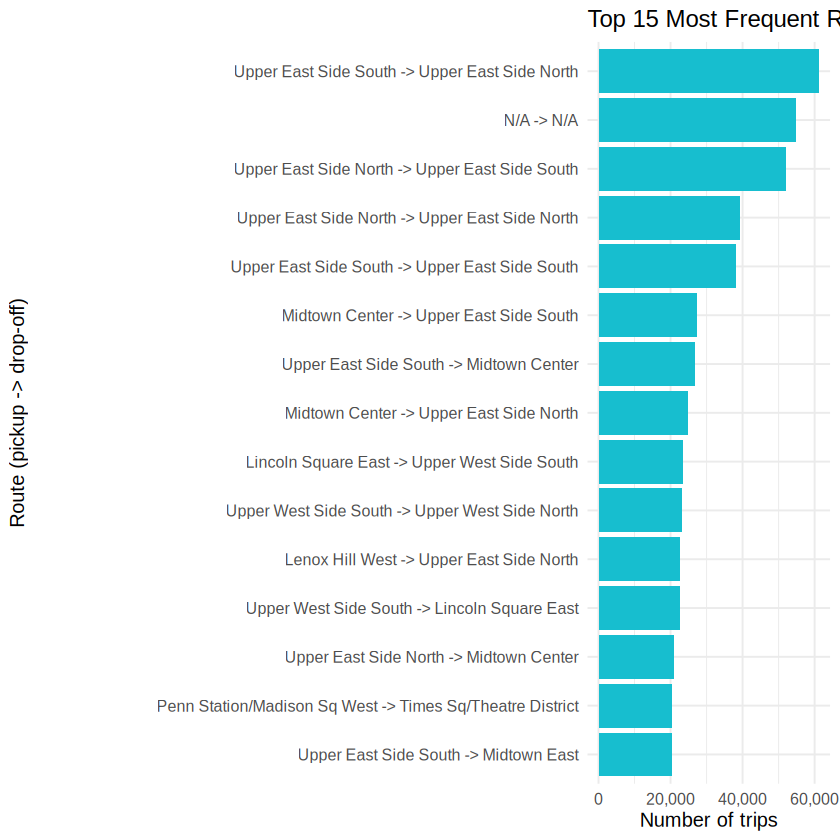

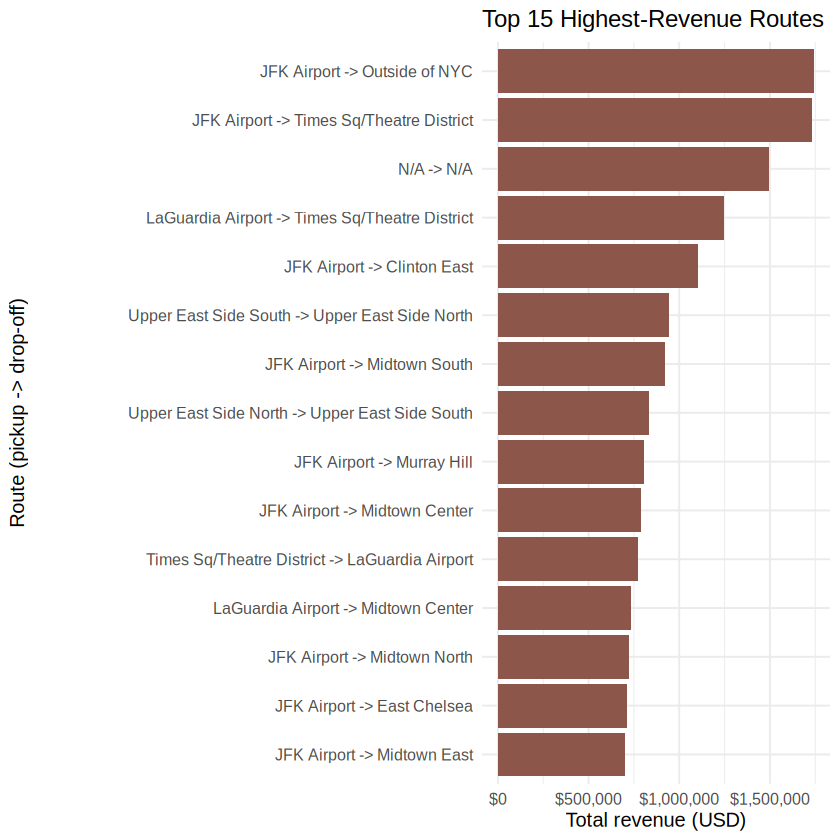

In [ ]:
ggplot(top_routes, aes(x = reorder(route, trips), y = trips)) +
    geom_col(fill = "#17becf") +
    coord_flip() +
    scale_y_continuous(labels = comma) +
    labs(title = "Top 15 Most Frequent Routes", x = "Route (pickup -> drop-off)", y = "Number of trips")

ggplot(top_revenue_routes, aes(x = reorder(route, revenue), y = revenue)) +
    geom_col(fill = "#8c564b") +
    coord_flip() +
    scale_y_continuous(labels = label_dollar()) +
    labs(title = "Top 15 Highest-Revenue Routes", x = "Route (pickup -> drop-off)", y = "Total revenue (USD)")

### 7.8 Payment-Type Distribution

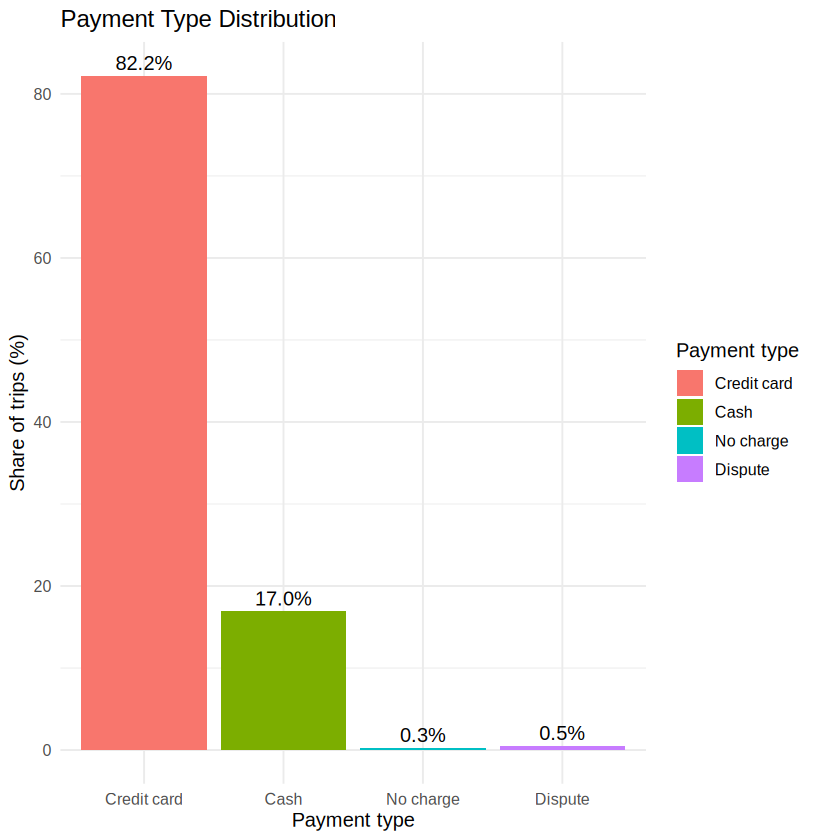

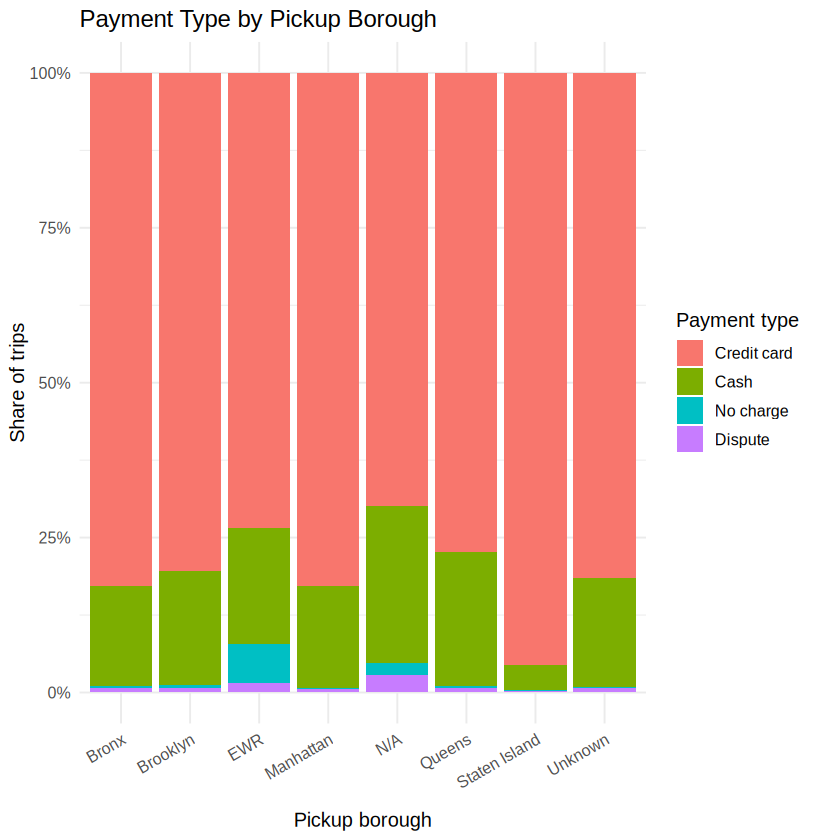

In [ ]:
pay_dist <- trips[, .N, by = payment_type][, share_pct := 100 * N / sum(N)]

ggplot(pay_dist, aes(x = payment_type, y = share_pct, fill = payment_type)) +
    geom_col() +
    geom_text(aes(label = sprintf("%.1f%%", share_pct)), vjust = -0.4) +
    labs(title = "Payment Type Distribution",
         x = "Payment type", y = "Share of trips (%)", fill = "Payment type")

ggplot(pay_borough, aes(x = PUBorough, y = N, fill = payment_type)) +
    geom_col(position = "fill") +
    scale_y_continuous(labels = percent) +
    labs(title = "Payment Type by Pickup Borough",
         x = "Pickup borough", y = "Share of trips", fill = "Payment type") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1))

### 7.9 Trip Distance vs Fare Amount

`geom_smooth()` using formula = 'y ~ x'


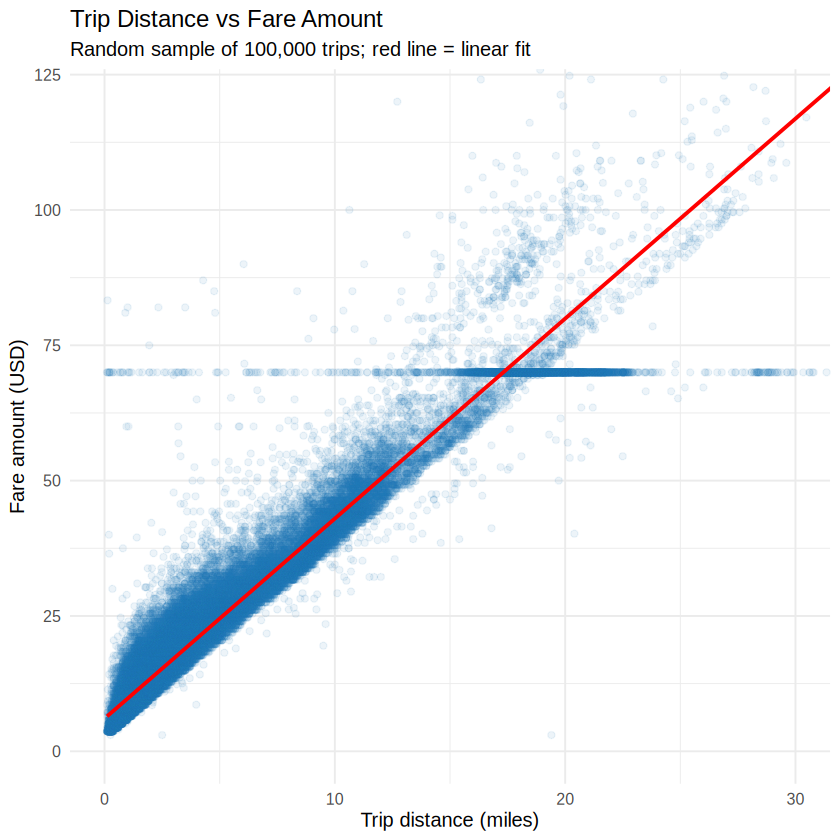

In [ ]:
plot_sample <- trips[sample(.N, 100000)]

ggplot(plot_sample, aes(x = trip_distance, y = fare_amount)) +
    geom_point(alpha = 0.08, colour = "#1f77b4") +
    geom_smooth(method = "lm", colour = "red", se = FALSE) +
    coord_cartesian(xlim = c(0, 30), ylim = c(0, 120)) +
    labs(title = "Trip Distance vs Fare Amount",
         subtitle = "Random sample of 100,000 trips; red line = linear fit",
         x = "Trip distance (miles)", y = "Fare amount (USD)")

## 8. Task 7: Critical Analysis and Recommendation

### 8.1 Fastest Method per Task (from Benchmark Results)

In [ ]:
best <- results_all[, .SD[which.min(median_ms)], by = task]
best

fastest_lapply <- results_all[task == "A: Avg fare per hour (9M rows)"]
cat("Speedup of data.table over lapply (task A):",
    round(fastest_lapply[method == "lapply_functional", median_ms] /
          fastest_lapply[method == "data_table", median_ms], 1), "x\n")
cat("Parallel speedup:", speedup_tbl$speedup, "x on", n_cores, "cores\n")

task,method,median_ms,rel_to_fastest
<chr>,<chr>,<dbl>,<dbl>
A: Avg fare per hour (9M rows),data_table,324.84,1
B: Row-wise tip % (100k rows),data_table_fifelse,1.79,1
C: Grouped mean (1M rows),data_table,48.25,1
"Sequential vs parallel (bootstrap, 21 partitions)",parallel_foreach_2_cores,28145.00,1


Speedup of data.table over lapply (task A): 3.8 x
Parallel speedup: 1.06 x on 2 cores
